✓ Loaded 8 years of data
  Period: 2015 - 2022
RETAILER REVENUE FORECASTING ANALYSIS

 DATA SUMMARY
----------------------------------------
  Period: 2015 - 2022 (8 years)
  Sales range: 3,445 → 4,795
  CAGR: 4.8%
  Avg annual growth: 5.6%
  Growth volatility: 12.6%

 HISTORICAL DATA
----------------------------------------
 year  sales  growth_pct outlier
 2015   3445         NaN        
 2016   3546         2.9        
 2017   3616         2.0        
 2018   3951         9.3        
 2019   3984         0.8        
 2020   3450       -13.4        
 2021   4549        31.9        
 2022   4795         5.4        

 BACKTESTING
----------------------------------------

 Backtest complete (holdout: 2 years)
  Best method: holt
       method  mape    bias   rmse
       linear 17.41  -815.4  821.4
         cagr 26.07 -1220.5 1226.6
exp_smoothing 24.48 -1147.4 1159.6
         holt 14.36  -672.6  677.1
     ma_trend 27.31 -1278.8 1286.6
 weighted_avg 28.22 -1321.4 1330.6

 FORECASTS
-----

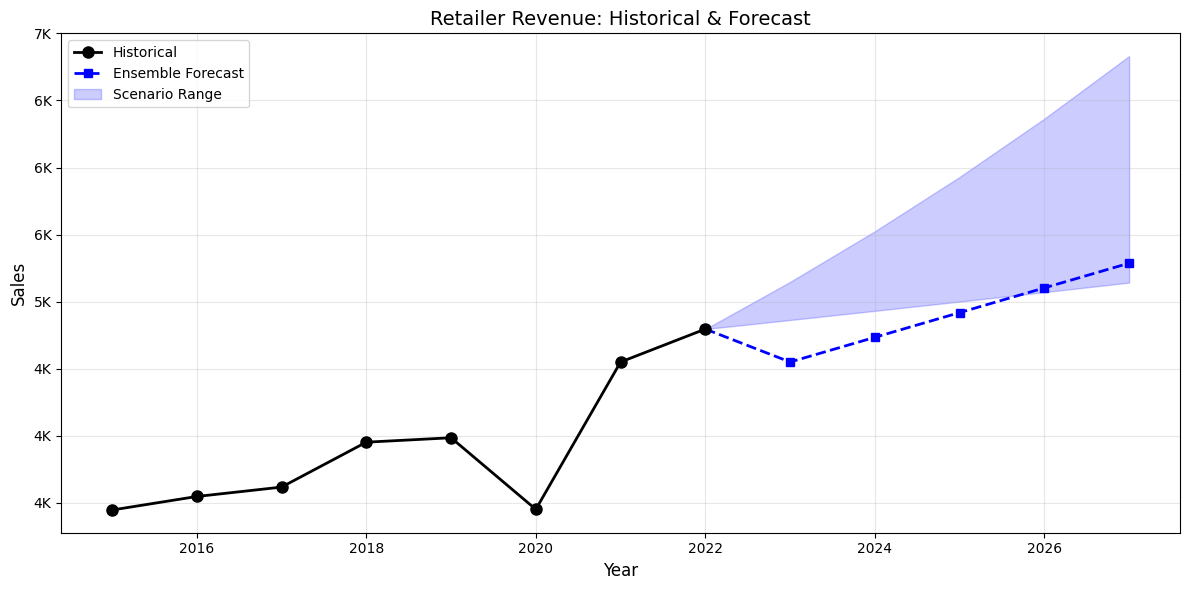

In [ ]:
#Main Code

"""
Retailer Annual Revenue Forecasting System
==========================================
Upload any Excel file with Year/Date and Sales columns.
Automatically generates 5-year forward projections.

Usage:
    forecaster = RetailerForecaster('Retailer.xlsx')
    forecaster.run_full_analysis()
    forecaster.export_results('forecast_output.xlsx')
"""

import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Optional: for visualization
try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except ImportError:
    PLOTTING_AVAILABLE = False


class RetailerForecaster:
    """
    Complete annual revenue forecasting system for retailers.
    Handles data loading, cleaning, model selection, and forecasting.
    """

    def __init__(self, file_path: str):
        """
        Initialize with an Excel file path.

        Args:
            file_path: Path to Excel (.xlsx or .xls) file
        """
        self.raw_data = None
        self.clean_data = None
        self.data_excluding_outliers = None
        self.outliers = []
        self.forecasts = {}
        self.backtest_results = {}
        self.best_method = None
        self.final_forecast = None
        self.actuals_comparison = None

        self.load_data(file_path)

    # =========================================================================
    # DATA LOADING & PREPARATION
    # =========================================================================

    def load_data(self, file_path: str) -> 'RetailerForecaster':
        """Load data from Excel file only."""
        if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
            self.raw_data = pd.read_excel(file_path)
        else:
            raise ValueError("Only Excel files (.xlsx, .xls) are supported.")

        self._prepare_data()
        return self

    def _prepare_data(self) -> None:
        """Clean and standardize the loaded data."""
        df = self.raw_data.copy()

        # Identify date/year column
        date_col = None
        for col in df.columns:
            col_lower = col.lower()
            if any(term in col_lower for term in ['date', 'year', 'period', 'time']):
                date_col = col
                break

        if date_col is None:
            date_col = df.columns[0]  # Assume first column is date

        # Identify sales/revenue column
        sales_col = None
        for col in df.columns:
            col_lower = col.lower()
            if any(term in col_lower for term in ['sales', 'revenue', 'amount', 'value']):
                sales_col = col
                break

        if sales_col is None:
            sales_col = df.columns[1]  # Assume second column is sales

        # Extract year from date column
        df['year'] = pd.to_datetime(df[date_col], errors='coerce').dt.year

        # If conversion failed, try treating as year directly
        if df['year'].isna().all():
            df['year'] = pd.to_numeric(df[date_col], errors='coerce')

        df['sales'] = pd.to_numeric(df[sales_col], errors='coerce')

        # Clean and sort
        self.clean_data = (
            df[['year', 'sales']]
            .dropna()
            .drop_duplicates(subset=['year'])
            .sort_values('year')
            .reset_index(drop=True)
        )

        self.clean_data['year'] = self.clean_data['year'].astype(int)

        # Detect outliers
        self._detect_outliers()

        print(f"✓ Loaded {len(self.clean_data)} years of data")
        print(f"  Period: {self.clean_data['year'].min()} - {self.clean_data['year'].max()}")
        if self.outliers:
            print(f"  Detected outliers: {self.outliers}")

    def _detect_outliers(self, threshold: float = 2.0) -> None:
        """Detect outlier years based on growth rate z-scores."""
        df = self.clean_data.copy()
        df['growth'] = df['sales'].pct_change()

        mean_growth = df['growth'].mean()
        std_growth = df['growth'].std()

        if std_growth > 0:
            df['z_score'] = (df['growth'] - mean_growth) / std_growth
            outlier_mask = df['z_score'].abs() > threshold
            self.outliers = df.loc[outlier_mask, 'year'].tolist()

        # Create dataset excluding outliers
        self.data_excluding_outliers = self.clean_data[
            ~self.clean_data['year'].isin(self.outliers)
        ].copy()

    # =========================================================================
    # SUMMARY STATISTICS
    # =========================================================================

    def summary_stats(self, exclude_outliers: bool = True) -> dict:
        """Calculate summary statistics for the data."""
        df = self.data_excluding_outliers if exclude_outliers else self.clean_data

        sales = df['sales'].values
        years = df['year'].values
        growth_rates = np.diff(sales) / sales[:-1]

        n_years = len(sales)
        cagr = (np.power(sales[-1] / sales[0], 1 / (n_years - 1)) - 1) if n_years > 1 else 0

        return {
            'n_years': n_years,
            'first_year': int(years[0]),
            'last_year': int(years[-1]),
            'first_sales': sales[0],
            'last_sales': sales[-1],
            'total_growth_pct': (sales[-1] / sales[0] - 1) * 100,
            'cagr_pct': cagr * 100,
            'avg_annual_growth_pct': np.mean(growth_rates) * 100 if len(growth_rates) > 0 else 0,
            'median_annual_growth_pct': np.median(growth_rates) * 100 if len(growth_rates) > 0 else 0,
            'growth_volatility_pct': np.std(growth_rates) * 100 if len(growth_rates) > 0 else 0,
            'min_growth_pct': np.min(growth_rates) * 100 if len(growth_rates) > 0 else 0,
            'max_growth_pct': np.max(growth_rates) * 100 if len(growth_rates) > 0 else 0,
            'outliers_excluded': self.outliers if exclude_outliers else []
        }

    # =========================================================================
    # FORECASTING METHODS
    # =========================================================================

    def _forecast_linear(self, years: np.ndarray, sales: np.ndarray, periods: int) -> dict:
        """Linear regression trend forecast."""
        slope, intercept, r_value, _, std_err = stats.linregress(years, sales)
        future_years = np.arange(years[-1] + 1, years[-1] + 1 + periods)
        forecast = intercept + slope * future_years

        # Confidence interval (approximate)
        n = len(years)
        se_forecast = std_err * np.sqrt(1 + 1/n + (future_years - np.mean(years))**2 / np.sum((years - np.mean(years))**2))
        ci_90_lower = forecast - 1.645 * se_forecast * np.sqrt(n)
        ci_90_upper = forecast + 1.645 * se_forecast * np.sqrt(n)

        return {
            'method': 'linear',
            'forecast': forecast,
            'years': future_years,
            'r_squared': r_value ** 2,
            'slope': slope,
            'ci_lower': ci_90_lower,
            'ci_upper': ci_90_upper
        }

    def _forecast_cagr(self, years: np.ndarray, sales: np.ndarray, periods: int,
                       lookback: int = None) -> dict:
        """CAGR-based projection."""
        if lookback and lookback < len(sales):
            base = sales[-lookback]
            n = lookback - 1
        else:
            base = sales[0]
            n = len(sales) - 1

        cagr = np.power(sales[-1] / base, 1 / n) - 1 if n > 0 else 0

        future_years = np.arange(years[-1] + 1, years[-1] + 1 + periods)
        forecast = np.array([sales[-1] * np.power(1 + cagr, i) for i in range(1, periods + 1)])

        return {
            'method': 'cagr',
            'forecast': forecast,
            'years': future_years,
            'cagr': cagr
        }

    def _forecast_exp_smoothing(self, years: np.ndarray, sales: np.ndarray,
                                 periods: int, alpha: float = 0.3) -> dict:
        """Simple exponential smoothing with trend."""
        smoothed = [sales[0]]
        for i in range(1, len(sales)):
            smoothed.append(alpha * sales[i] + (1 - alpha) * smoothed[-1])

        trend = smoothed[-1] - smoothed[-2] if len(smoothed) > 1 else 0

        future_years = np.arange(years[-1] + 1, years[-1] + 1 + periods)
        forecast = np.array([smoothed[-1] + trend * i for i in range(1, periods + 1)])

        return {
            'method': 'exp_smoothing',
            'forecast': forecast,
            'years': future_years,
            'alpha': alpha,
            'final_level': smoothed[-1],
            'trend': trend
        }

    def _forecast_holt(self, years: np.ndarray, sales: np.ndarray, periods: int,
                       alpha: float = 0.3, beta: float = 0.1) -> dict:
        """Holt's linear trend method."""
        level = sales[0]
        trend = sales[1] - sales[0] if len(sales) > 1 else 0

        for i in range(1, len(sales)):
            prev_level = level
            level = alpha * sales[i] + (1 - alpha) * (level + trend)
            trend = beta * (level - prev_level) + (1 - beta) * trend

        future_years = np.arange(years[-1] + 1, years[-1] + 1 + periods)
        forecast = np.array([level + trend * i for i in range(1, periods + 1)])

        return {
            'method': 'holt',
            'forecast': forecast,
            'years': future_years,
            'alpha': alpha,
            'beta': beta,
            'final_level': level,
            'final_trend': trend
        }

    def _forecast_ma_trend(self, years: np.ndarray, sales: np.ndarray,
                           periods: int, window: int = 3) -> dict:
        """Moving average of growth rates projection."""
        growth_rates = np.diff(sales) / sales[:-1]
        avg_growth = np.mean(growth_rates[-window:]) if len(growth_rates) >= window else np.mean(growth_rates)

        future_years = np.arange(years[-1] + 1, years[-1] + 1 + periods)
        forecast = []
        last = sales[-1]
        for _ in range(periods):
            last = last * (1 + avg_growth)
            forecast.append(last)

        return {
            'method': 'ma_trend',
            'forecast': np.array(forecast),
            'years': future_years,
            'avg_growth': avg_growth
        }

    def _forecast_weighted_avg(self, years: np.ndarray, sales: np.ndarray,
                                periods: int) -> dict:
        """Weighted average growth (more weight on recent years)."""
        growth_rates = np.diff(sales) / sales[:-1]
        weights = np.arange(1, len(growth_rates) + 1)  # Linear weights
        weighted_growth = np.average(growth_rates, weights=weights)

        future_years = np.arange(years[-1] + 1, years[-1] + 1 + periods)
        forecast = []
        last = sales[-1]
        for _ in range(periods):
            last = last * (1 + weighted_growth)
            forecast.append(last)

        return {
            'method': 'weighted_avg',
            'forecast': np.array(forecast),
            'years': future_years,
            'weighted_growth': weighted_growth
        }

    # =========================================================================
    # MODEL SELECTION & BACKTESTING
    # =========================================================================

    def backtest(self, holdout_years: int = 2, exclude_outliers: bool = True) -> pd.DataFrame:
        """
        Backtest all methods by holding out recent years.
        Returns comparison DataFrame.
        """
        df = self.data_excluding_outliers if exclude_outliers else self.clean_data

        if len(df) <= holdout_years + 2:
            print(f" Not enough data for {holdout_years}-year holdout. Using leave-one-out.")
            holdout_years = 1

        train = df.iloc[:-holdout_years]
        test = df.iloc[-holdout_years:]

        train_years = train['year'].values
        train_sales = train['sales'].values
        actual = test['sales'].values

        methods = {
            'linear': self._forecast_linear,
            'cagr': self._forecast_cagr,
            'exp_smoothing': self._forecast_exp_smoothing,
            'holt': self._forecast_holt,
            'ma_trend': self._forecast_ma_trend,
            'weighted_avg': self._forecast_weighted_avg
        }

        results = []
        for name, method in methods.items():
            try:
                result = method(train_years, train_sales, holdout_years)
                predicted = result['forecast']

                mape = np.mean(np.abs(predicted - actual) / actual) * 100
                bias = np.mean(predicted - actual)
                rmse = np.sqrt(np.mean((predicted - actual) ** 2))

                results.append({
                    'method': name,
                    'mape': round(mape, 2),
                    'bias': round(bias, 1),
                    'rmse': round(rmse, 1),
                    'predicted': predicted,
                    'actual': actual
                })
            except Exception as e:
                print(f"  Method {name} failed: {e}")

        self.backtest_results = pd.DataFrame(results)
        self.best_method = self.backtest_results.loc[
            self.backtest_results['mape'].idxmin(), 'method'
        ]

        print(f"\n Backtest complete (holdout: {holdout_years} years)")
        print(f"  Best method: {self.best_method}")

        return self.backtest_results[['method', 'mape', 'bias', 'rmse']]

    # =========================================================================
    # GENERATE FORECASTS
    # =========================================================================

    def forecast(self, periods: int = 5, exclude_outliers: bool = True) -> pd.DataFrame:
        """
        Generate forecasts using all methods and create ensemble.

        Args:
            periods: Number of years to forecast (default: 5)
            exclude_outliers: Whether to exclude detected outlier years

        Returns:
            DataFrame with forecasts from all methods
        """
        df = self.data_excluding_outliers if exclude_outliers else self.clean_data
        years = df['year'].values
        sales = df['sales'].values

        # Run all methods
        self.forecasts = {
            'linear': self._forecast_linear(years, sales, periods),
            'cagr': self._forecast_cagr(years, sales, periods),
            'exp_smoothing': self._forecast_exp_smoothing(years, sales, periods),
            'holt': self._forecast_holt(years, sales, periods),
            'ma_trend': self._forecast_ma_trend(years, sales, periods),
            'weighted_avg': self._forecast_weighted_avg(years, sales, periods)
        }

        # Build results DataFrame
        future_years = self.forecasts['linear']['years']
        results = pd.DataFrame({'year': future_years})

        for name, forecast in self.forecasts.items():
            results[name] = np.round(forecast['forecast'], 1)

        # Ensemble: average of top methods (or all if no backtest)
        if self.backtest_results is not None and len(self.backtest_results) > 0:
            top_methods = self.backtest_results.nsmallest(3, 'mape')['method'].tolist()
        else:
            top_methods = ['holt', 'cagr', 'weighted_avg']

        results['ensemble'] = np.round(
            results[top_methods].mean(axis=1), 1
        )

        # Scenario analysis
        growth_rates = np.diff(sales) / sales[:-1]
        scenarios = {
            'pessimistic': np.percentile(growth_rates, 25),
            'baseline': np.median(growth_rates),
            'optimistic': np.percentile(growth_rates, 75)
        }

        for scenario, growth in scenarios.items():
            scenario_forecast = []
            last = sales[-1]
            for _ in range(periods):
                last = last * (1 + growth)
                scenario_forecast.append(last)
            results[f'scenario_{scenario}'] = np.round(scenario_forecast, 1)

        self.final_forecast = results

        print(f"\n Generated {periods}-year forecast")
        print(f"  Forecast period: {int(future_years[0])} - {int(future_years[-1])}")

        return results

    # =========================================================================
    # COMPLETE ANALYSIS
    # =========================================================================

    def run_full_analysis(self, forecast_periods: int = 5, holdout_years: int = 2) -> dict:
        """Run complete analysis pipeline."""
        print("=" * 60)
        print("RETAILER REVENUE FORECASTING ANALYSIS")
        print("=" * 60)

        # Summary stats
        print("\n DATA SUMMARY")
        print("-" * 40)
        stats = self.summary_stats()
        print(f"  Period: {stats['first_year']} - {stats['last_year']} ({stats['n_years']} years)")
        print(f"  Sales range: {stats['first_sales']:,.0f} → {stats['last_sales']:,.0f}")
        print(f"  CAGR: {stats['cagr_pct']:.1f}%")
        print(f"  Avg annual growth: {stats['avg_annual_growth_pct']:.1f}%")
        print(f"  Growth volatility: {stats['growth_volatility_pct']:.1f}%")
        if stats['outliers_excluded']:
            print(f"  Outliers excluded: {stats['outliers_excluded']}")

        # Historical data table
        print("\n HISTORICAL DATA")
        print("-" * 40)
        historical = self.clean_data.copy()
        historical['growth_pct'] = (historical['sales'].pct_change() * 100).round(1)
        historical['outlier'] = historical['year'].isin(self.outliers).map({True: '⚠', False: ''})
        print(historical.to_string(index=False))

        # Backtesting
        print("\n BACKTESTING")
        print("-" * 40)
        backtest = self.backtest(holdout_years=holdout_years)
        print(backtest.to_string(index=False))

        # Forecasting
        print("\n FORECASTS")
        print("-" * 40)
        forecast = self.forecast(periods=forecast_periods)

        # Display clean forecast table
        display_cols = ['year', 'ensemble', 'scenario_pessimistic', 'scenario_baseline', 'scenario_optimistic']
        available_cols = [c for c in display_cols if c in forecast.columns]
        print(forecast[available_cols].to_string(index=False))

        # Growth rates
        print("\n IMPLIED GROWTH RATES")
        print("-" * 40)
        last_actual = self.clean_data['sales'].iloc[-1]
        all_values = [last_actual] + forecast['ensemble'].tolist()
        growth_rates = [(all_values[i+1]/all_values[i] - 1) * 100 for i in range(len(all_values)-1)]

        growth_df = pd.DataFrame({
            'year': forecast['year'],
            'forecast': forecast['ensemble'],
            'yoy_growth_pct': [round(g, 1) for g in growth_rates]
        })
        print(growth_df.to_string(index=False))

        print("\n" + "=" * 60)
        print("ANALYSIS COMPLETE")
        print("=" * 60)

        return {
            'summary_stats': stats,
            'historical_data': historical,
            'backtest_results': backtest,
            'forecasts': forecast,
            'best_method': self.best_method
        }

    # =========================================================================
    # EXPORT RESULTS
    # =========================================================================

    def export_results(self, file_path: str = 'forecast_results.xlsx') -> None:
        """Export all results to Excel file."""
        with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
            # Historical data
            historical = self.clean_data.copy()
            historical['growth_pct'] = (historical['sales'].pct_change() * 100).round(1)
            historical.to_excel(writer, sheet_name='Historical', index=False)

            # Backtest results
            if self.backtest_results is not None and len(self.backtest_results) > 0:
                self.backtest_results[['method', 'mape', 'bias', 'rmse']].to_excel(
                    writer, sheet_name='Backtest', index=False
                )

            # Forecasts
            if self.final_forecast is not None:
                self.final_forecast.to_excel(writer, sheet_name='Forecasts', index=False)

            # Summary stats
            stats = self.summary_stats()
            stats_df = pd.DataFrame([stats])
            stats_df.to_excel(writer, sheet_name='Summary', index=False)

        print(f"\n Results exported to: {file_path}")

    # =========================================================================
    # VISUALIZATION
    # =========================================================================

    def plot(self, save_path: str = None) -> None:
        """Generate forecast visualization."""
        if not PLOTTING_AVAILABLE:
            print(" matplotlib not available. Install with: pip install matplotlib")
            return

        fig, ax = plt.subplots(figsize=(12, 6))

        # Historical data
        historical = self.clean_data
        ax.plot(historical['year'], historical['sales'], 'ko-',
                linewidth=2, markersize=8, label='Historical', zorder=5)

        # Mark outliers
        if self.outliers:
            outlier_data = historical[historical['year'].isin(self.outliers)]
            ax.scatter(outlier_data['year'], outlier_data['sales'],
                      color='red', s=150, zorder=6, label='Outliers', marker='x')

        # Forecasts
        if self.final_forecast is not None:
            forecast = self.final_forecast
            last_year = historical['year'].iloc[-1]
            last_sales = historical['sales'].iloc[-1]

            # Ensemble forecast
            years = np.concatenate([[last_year], forecast['year'].values])
            ensemble = np.concatenate([[last_sales], forecast['ensemble'].values])
            ax.plot(years, ensemble, 'b--', linewidth=2, marker='s',
                   markersize=6, label='Ensemble Forecast')

            # Confidence band (scenarios)
            if 'scenario_pessimistic' in forecast.columns:
                pessimistic = np.concatenate([[last_sales], forecast['scenario_pessimistic'].values])
                optimistic = np.concatenate([[last_sales], forecast['scenario_optimistic'].values])
                ax.fill_between(years, pessimistic, optimistic,
                               alpha=0.2, color='blue', label='Scenario Range')

        ax.set_xlabel('Year', fontsize=12)
        ax.set_ylabel('Sales', fontsize=12)
        ax.set_title('Retailer Revenue: Historical & Forecast', fontsize=14)
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        # Format y-axis
        max_val = ax.get_ylim()[1]
        if max_val >= 1_000_000:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
        elif max_val >= 1_000:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Chart saved to: {save_path}")

        plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    forecaster = RetailerForecaster('Retailer.xlsx')
    results = forecaster.run_full_analysis(forecast_periods=5)
    forecaster.export_results('forecast_output.xlsx')
    forecaster.plot(save_path='forecast_chart.png')